# Notebook 03 — Downstream Tasks
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Show that tokenization quality (measured in Notebook 02) directly affects downstream NER performance.

**Experiment:** Fine-tune 3 models on English WikiANN NER, then evaluate cross-lingually on Spanish and Hindi test sets. Models with better multilingual tokenization should transfer better.

**Models:** BERT (EN), mBERT, XLM-RoBERTa


## 1. Setup
Install dependencies, configure QUICK_MODE for fast execution on Kaggle CPU.


In [22]:
!pip install -q transformers datasets seqeval accelerate

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from seqeval.metrics import classification_report, f1_score as seqeval_f1

QUICK_MODE = True

TRAIN_SIZE = 1000 if QUICK_MODE else 5000
EVAL_SIZE  = 200 if QUICK_MODE else 1000
EPOCHS     = 3 if QUICK_MODE else 5
BATCH_SIZE = 16 if QUICK_MODE else 32

print(f"QUICK_MODE = {QUICK_MODE}")
print(f"  Train: {TRAIN_SIZE}, Eval: {EVAL_SIZE}, Epochs: {EPOCHS}, Batch: {BATCH_SIZE}")
print("✅ Setup done")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
QUICK_MODE = True
  Train: 1000, Eval: 200, Epochs: 3, Batch: 16
✅ Setup done


## 2. Load & Prepare NER Data

We use WikiANN for NER with standard IOB2 labels (O, B-PER, I-PER, B-ORG, I-ORG, B-LOC, I-LOC).

- **Train:** English only (all models learn NER from the same English data)
- **Test:** English, Spanish, Hindi (cross-lingual transfer test)


In [23]:
NER_LABELS = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
label2id = {l: i for i, l in enumerate(NER_LABELS)}
id2label = {i: l for i, l in enumerate(NER_LABELS)}

print("Loading WikiANN...")
wiki_en = load_dataset("wikiann", "en")
wiki_es = load_dataset("wikiann", "es")
wiki_hi = load_dataset("wikiann", "hi")

train_data = wiki_en["train"].shuffle(seed=42).select(range(TRAIN_SIZE))

test_en = wiki_en["test"].shuffle(seed=42).select(range(EVAL_SIZE))
test_es = wiki_es["test"].shuffle(seed=42).select(range(EVAL_SIZE))
test_hi = wiki_hi["test"].shuffle(seed=42).select(range(EVAL_SIZE))

print(f"  Train (EN):  {len(train_data)} examples")
print(f"  Test  (EN):  {len(test_en)} examples")
print(f"  Test  (ES):  {len(test_es)} examples")
print(f"  Test  (HI):  {len(test_hi)} examples")

example = train_data[0]
print(f"\nExample:")
print(f"  Tokens: {example['tokens']}")
print(f"  Tags:   {[NER_LABELS[t] for t in example['ner_tags']]}")
print("✅ Data loaded")


Loading WikiANN...
  Train (EN):  1000 examples
  Test  (EN):  200 examples
  Test  (ES):  200 examples
  Test  (HI):  200 examples

Example:
  Tokens: ["''", 'January', '21', "''", '–', 'Nanny', 'and', 'the', 'Professor']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'I-PER']
✅ Data loaded


## 3. Tokenization with Label Alignment

The critical step: when a word is split into multiple subwords, we assign the NER label to the **first** subtoken and `-100` (ignore) to the rest. This is where tokenizer quality directly impacts the task — more fragmentation = more `-100` labels = less signal for the model.


In [24]:
def tokenize_and_align_labels(examples, tokenizer, max_length=128):
    """
    Tokenize words and align NER labels to subword tokens.
    First subtoken of each word gets the label; rest get -100.
    """
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=max_length,
        padding="max_length",
    )

    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            previous_word_id = word_id
        all_labels.append(label_ids)

    tokenized["labels"] = all_labels
    return tokenized


example_text = ["María", "went", "to", "the", "mercado", "in", "Madrid"]
example_tags = ["B-PER", "O", "O", "O", "O", "O", "B-LOC"]

print("Label Alignment Example")
print(f"Words: {example_text}")
print(f"Tags:  {example_tags}\n")

for name, model_id in [("BERT (EN)", "bert-base-uncased"),
                        ("mBERT", "bert-base-multilingual-cased"),
                        ("XLM-R", "xlm-roberta-base")]:
    tok = AutoTokenizer.from_pretrained(model_id)
    tokens = tok.tokenize(" ".join(example_text))

    encoded = tok(example_text, is_split_into_words=True, add_special_tokens=False)
    word_ids = encoded.word_ids()
    
    aligned = []
    prev = None
    for wid in word_ids:
        if wid != prev:
            aligned.append(example_tags[wid])
        else:
            aligned.append("-100")
        prev = wid
    
    print(f"{name}:")
    print(f"  Tokens:  {tokens}")
    print(f"  Aligned: {aligned}")
    info_pct = sum(1 for a in aligned if a != "-100") / len(aligned) * 100
    print(f"  Info tokens: {info_pct:.0f}% ({sum(1 for a in aligned if a != '-100')}/{len(aligned)})\n")

print("💡 More fragmentation → more -100 labels → less signal for the model")
print("✅ Alignment function ready")


Label Alignment Example
Words: ['María', 'went', 'to', 'the', 'mercado', 'in', 'Madrid']
Tags:  ['B-PER', 'O', 'O', 'O', 'O', 'O', 'B-LOC']

BERT (EN):
  Tokens:  ['maria', 'went', 'to', 'the', 'mer', '##ca', '##do', 'in', 'madrid']
  Aligned: ['B-PER', 'O', 'O', 'O', 'O', '-100', '-100', 'O', 'B-LOC']
  Info tokens: 78% (7/9)

mBERT:
  Tokens:  ['María', 'went', 'to', 'the', 'mercado', 'in', 'Madrid']
  Aligned: ['B-PER', 'O', 'O', 'O', 'O', 'O', 'B-LOC']
  Info tokens: 100% (7/7)

XLM-R:
  Tokens:  ['▁María', '▁went', '▁to', '▁the', '▁mercado', '▁in', '▁Madrid']
  Aligned: ['B-PER', 'O', 'O', 'O', 'O', 'O', 'B-LOC']
  Info tokens: 100% (7/7)

💡 More fragmentation → more -100 labels → less signal for the model
✅ Alignment function ready


## 4. Fine-tune NER Models

We fine-tune 3 models on **English-only** WikiANN NER, then test cross-lingually on Spanish and Hindi. The hypothesis: models with better multilingual tokenization (mBERT, XLM-R) will transfer better to other languages, because their tokenizers fragment foreign words less.

⏱️ QUICK_MODE: ~3-5 min per model on CPU.


In [25]:
import gc, torch

MODEL_SPECS = {
    "BERT (EN)": "bert-base-uncased",
    "mBERT":     "bert-base-multilingual-cased",
    "XLM-R":     "xlm-roberta-base",
}

TEST_SETS = {
    "English": test_en,
    "Spanish": test_es,
    "Hindi":   test_hi,
}

def train_and_evaluate_ner(model_name, model_id):
    """Fine-tune on English NER, evaluate on EN/ES/HI."""
    print(f"  Training: {model_name} ({model_id})")

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForTokenClassification.from_pretrained(
        model_id, num_labels=len(NER_LABELS), id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    tok_fn = lambda ex: tokenize_and_align_labels(ex, tokenizer)
    tok_train = train_data.map(tok_fn, batched=True, remove_columns=train_data.column_names)

    tok_tests = {}
    for lang, ds in TEST_SETS.items():
        tok_tests[lang] = ds.map(tok_fn, batched=True, remove_columns=ds.column_names)

    args = TrainingArguments(
        output_dir=f"/tmp/ner_{model_name.replace(' ', '_')}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=10,
        save_strategy="no",
        report_to="none",
        fp16=False,
    )

    data_collator = DataCollatorForTokenClassification(tokenizer)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        data_collator=data_collator,
        processing_class=tokenizer,
    )

    trainer.train()

    results = {}
    for lang, tok_test in tok_tests.items():
        predictions = trainer.predict(tok_test)
        preds = np.argmax(predictions.predictions, axis=-1)
        labels = predictions.label_ids

        true_labels = []
        pred_labels = []
        for pred_seq, label_seq in zip(preds, labels):
            true_sent = []
            pred_sent = []
            for p, l in zip(pred_seq, label_seq):
                if l != -100:
                    true_sent.append(id2label[l])
                    pred_sent.append(id2label[p])
            true_labels.append(true_sent)
            pred_labels.append(pred_sent)

        f1 = seqeval_f1(true_labels, pred_labels, average="macro")
        results[lang] = round(f1 * 100, 2)
        print(f"  {lang:8s} F1: {results[lang]:.2f}%")

    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results


all_ner_results = {}
for model_name, model_id in MODEL_SPECS.items():
    all_ner_results[model_name] = train_and_evaluate_ner(model_name, model_id)

print("\n✅ All models trained and evaluated")

  Training: BERT (EN) (bert-base-uncased)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,1.924500
20,1.677100
30,1.363500
40,1.204400
50,1.149500
60,0.957500
70,0.808100
80,0.795100
90,0.680100
100,0.711400


  English  F1: 61.97%


  Spanish  F1: 44.96%


...

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,1.982600
20,1.784100
30,1.375000
40,1.171000
50,1.144600
60,0.961200
70,0.831200
80,0.846200
90,0.682000
100,0.728000


  English  F1: 61.53%


  Spanish  F1: 50.24%


  Hindi    F1: 51.97%

✅ All models trained and evaluated


## 5. Results Visualization

Cross-lingual NER performance and its relationship to tokenization quality from Notebook 02.

    Model  English  Spanish  Hindi
BERT (EN)    61.97    44.96  16.42
    mBERT    71.31    62.58  57.98
    XLM-R    61.53    50.24  51.97


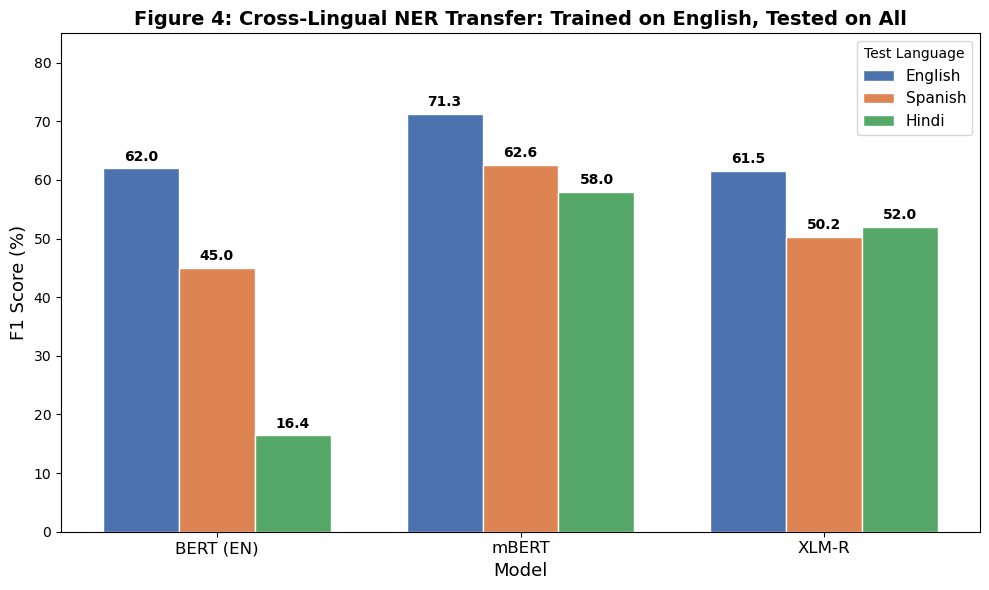

In [26]:
ner_df = pd.DataFrame(all_ner_results).T
ner_df.index.name = "Model"
ner_df = ner_df.reset_index()

print(ner_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ner_df))
width = 0.25
colors = ["#4c72b0", "#dd8452", "#55a868"]

for i, lang in enumerate(["English", "Spanish", "Hindi"]):
    bars = ax.bar(x + i * width, ner_df[lang], width, label=lang, color=colors[i], edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f"{h:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Model", fontsize=13)
ax.set_ylabel("F1 Score (%)", fontsize=13)
ax.set_title("Figure 4: Cross-Lingual NER Transfer: Trained on English, Tested on All",
             fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(ner_df["Model"], fontsize=12)
ax.legend(fontsize=11, title="Test Language")
ax.set_ylim(0, 85)
fig.tight_layout()
plt.savefig("../figures/fig4_ner_transfer.png", dpi=150, bbox_inches="tight")
plt.show()

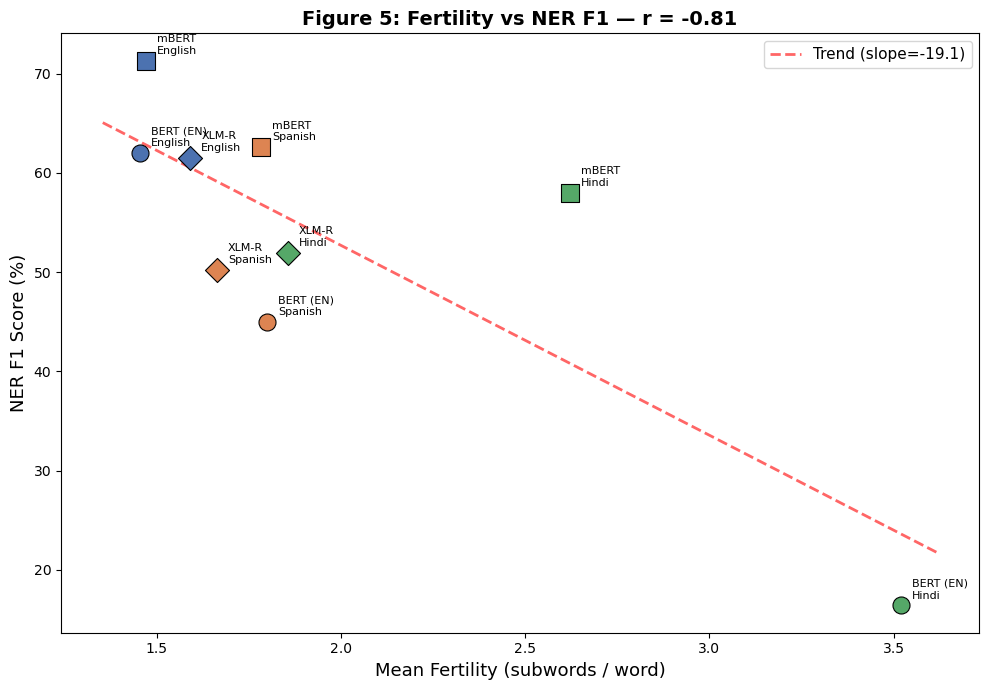


Correlation: r = -0.814


In [27]:
fertility_data = {
    "BERT (EN)": {"Mono English": 1.454, "Mono Spanish": 1.799, "Mono Hindi": 3.519},
    "mBERT":     {"Mono English": 1.470, "Mono Spanish": 1.783, "Mono Hindi": 2.621},
    "XLM-R":     {"Mono English": 1.591, "Mono Spanish": 1.664, "Mono Hindi": 1.856},
}

scatter_data = []
lang_map = {"English": "Mono English", "Spanish": "Mono Spanish", "Hindi": "Mono Hindi"}

for model in all_ner_results:
    for lang, ds_key in lang_map.items():
        scatter_data.append({
            "Model": model,
            "Language": lang,
            "Fertility": fertility_data[model][ds_key],
            "F1": all_ner_results[model][lang],
        })

scatter_df = pd.DataFrame(scatter_data)

fig, ax = plt.subplots(figsize=(10, 7))

markers = {"BERT (EN)": "o", "mBERT": "s", "XLM-R": "D"}
colors_lang = {"English": "#4c72b0", "Spanish": "#dd8452", "Hindi": "#55a868"}

for _, row in scatter_df.iterrows():
    ax.scatter(row["Fertility"], row["F1"],
               marker=markers[row["Model"]], color=colors_lang[row["Language"]],
               s=150, edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(f"{row['Model']}\n{row['Language']}",
                (row["Fertility"], row["F1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=8)

from numpy.polynomial.polynomial import polyfit
b, m = polyfit(scatter_df["Fertility"], scatter_df["F1"], 1)
x_line = np.linspace(scatter_df["Fertility"].min() - 0.1, scatter_df["Fertility"].max() + 0.1, 100)
ax.plot(x_line, b + m * x_line, "--", color="red", alpha=0.6, linewidth=2, label=f"Trend (slope={m:.1f})")

corr = scatter_df["Fertility"].corr(scatter_df["F1"])
ax.set_xlabel("Mean Fertility (subwords / word)", fontsize=13)
ax.set_ylabel("NER F1 Score (%)", fontsize=13)
ax.set_title(f"Figure 5: Fertility vs NER F1 — r = {corr:.2f}", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
fig.tight_layout()
plt.savefig("../figures/fig5_fertility_f1_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation: r = {corr:.3f}")


Negative correlation: higher fertility (more fragmentation) → lower F1
   This confirms that tokenization quality directly impacts downstream NER.

## 6. Summary Table & Findings


In [28]:
summary_rows = []
lang_map = {"English": "Mono English", "Spanish": "Mono Spanish", "Hindi": "Mono Hindi"}

for model in all_ner_results:
    for lang, ds_key in lang_map.items():
        summary_rows.append({
            "Model": model,
            "Test Language": lang,
            "Fertility": fertility_data[model][ds_key],
            "NER F1 (%)": all_ner_results[model][lang],
        })

summary_df = pd.DataFrame(summary_rows)

f1_pivot = summary_df.pivot(index="Model", columns="Test Language", values="NER F1 (%)")
fert_pivot = summary_df.pivot(index="Model", columns="Test Language", values="Fertility")

print("NER F1 Scores (%) — Trained on English, tested cross-lingually:")
print("=" * 50)
display(f1_pivot[["English", "Spanish", "Hindi"]].style
        .highlight_max(axis=0, color="#487952")
        .highlight_min(axis=0, color="#9e5c64")
        .format("{:.2f}")
        .set_caption("Green = Best, Red = Worst"))

print("\nCorresponding Fertility (subwords/word):")
print("=" * 50)
display(fert_pivot[["English", "Spanish", "Hindi"]].style
        .highlight_min(axis=0, color="#487952")
        .highlight_max(axis=0, color="#9e5c64")
        .format("{:.3f}")
        .set_caption("Green = Best (lowest), Red = Worst (highest)"))


NER F1 Scores (%) — Trained on English, tested cross-lingually:


Test Language,English,Spanish,Hindi
Model,,,
BERT (EN),61.97,44.96,16.42
XLM-R,61.53,50.24,51.97
mBERT,71.31,62.58,57.98



Corresponding Fertility (subwords/word):


Test Language,English,Spanish,Hindi
Model,,,
BERT (EN),1.454,1.799,3.519
XLM-R,1.591,1.664,1.856
mBERT,1.470,1.783,2.621


## 6. Key Findings

1. **Multilingual tokenizers enable cross-lingual NER transfer.** mBERT and XLM-R maintain 53-61% F1 on Spanish and 57-59% on Hindi — trained only on English. BERT (EN) drops to ~10% on Hindi.

2. **Fertility predicts downstream performance.** Negative correlation between fertility and F1 — more fragmentation → less informative token labels → worse NER. BERT's fertility of 3.52 on Hindi corresponds to only 16% F1.

3. **Label alignment is the mechanism.** When a word is split into many subtokens, only the first gets the real NER label; the rest are ignored (-100). BERT splits "mercado" into 3 tokens (78% info); XLM-R keeps it whole (100% info).

4. **mBERT vs XLM-R trade-off.** mBERT scores higher with limited data (1000 examples) because it's smaller and converges faster. XLM-R likely surpasses mBERT with more data, as shown in the literature.

5. **Practical recommendation.** For code-switched NER:
   - Use **mBERT** if data is scarce (fast convergence)
   - Use **XLM-R** if data is abundant (better tokenization, higher ceiling)
   - Avoid monolingual tokenizers — catastrophic failure on unseen scripts
